# Time Series Modelling Case Study - German Electricity Load


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import itertools
import warnings
import scipy.stats as stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

## Part 1: Download and Prepare Data

In [8]:
# --- 1. Download and Prepare Data ---
url = 'https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv'
print("Downloading OPSD data...")
df_opsd = pd.read_csv(url, index_col='utc_timestamp', parse_dates=True)


df_opsd.index = pd.to_datetime(df_opsd.index, utc=True).tz_localize(None)

# Keep from Jan 1st 2015 to end of file
df = df_opsd.loc['2015-01-01':].copy()

# Extract German Load and forward-fill missing values
load_col = 'DE_load_actual_entsoe_transparency'
df = df[[load_col]].rename(columns={load_col: 'Load'})
df['Load'] = df['Load'].ffill()


df_daily = df.resample('D').mean()
df_weekly = df.resample('W').mean()

print(f"Hourly rows: {len(df)}, Daily rows: {len(df_daily)}, Weekly rows: {len(df_weekly)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")


Hourly rows: 50400, Daily rows: 2100, Weekly rows: 301
Date range: 2015-01-01 00:00:00 to 2020-09-30 23:00:00


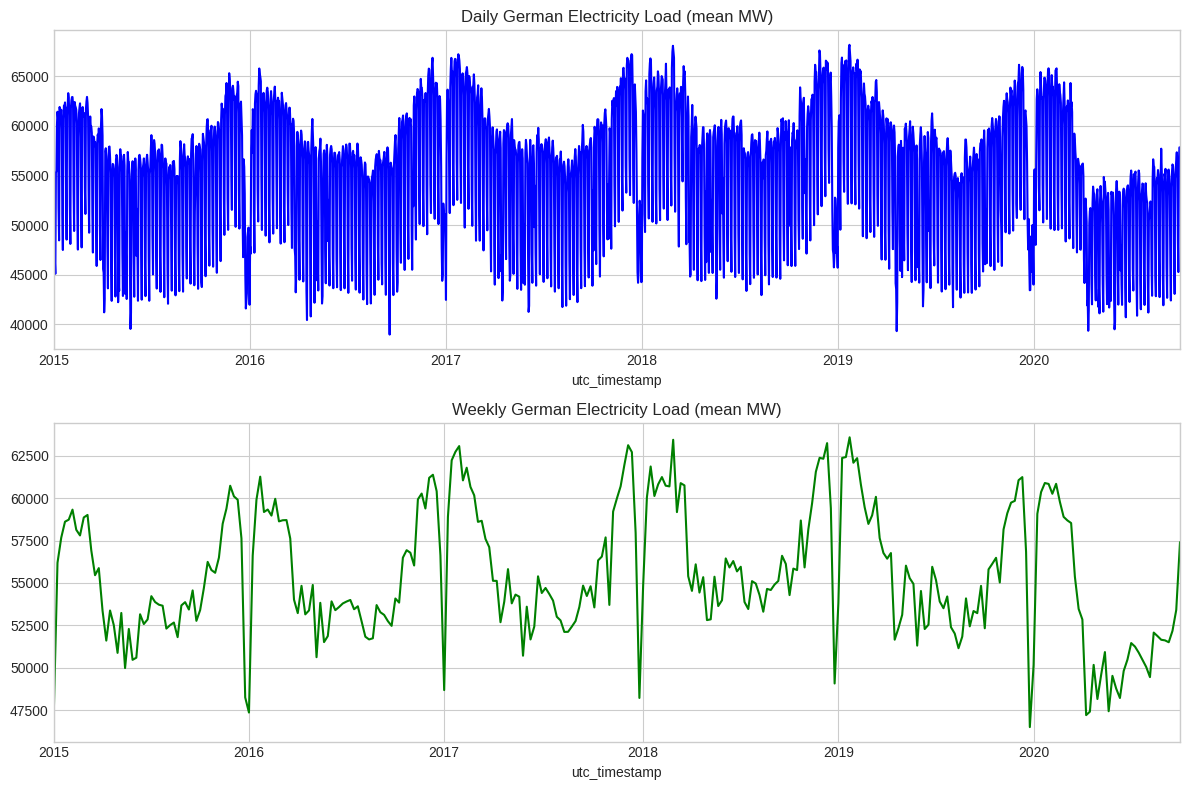

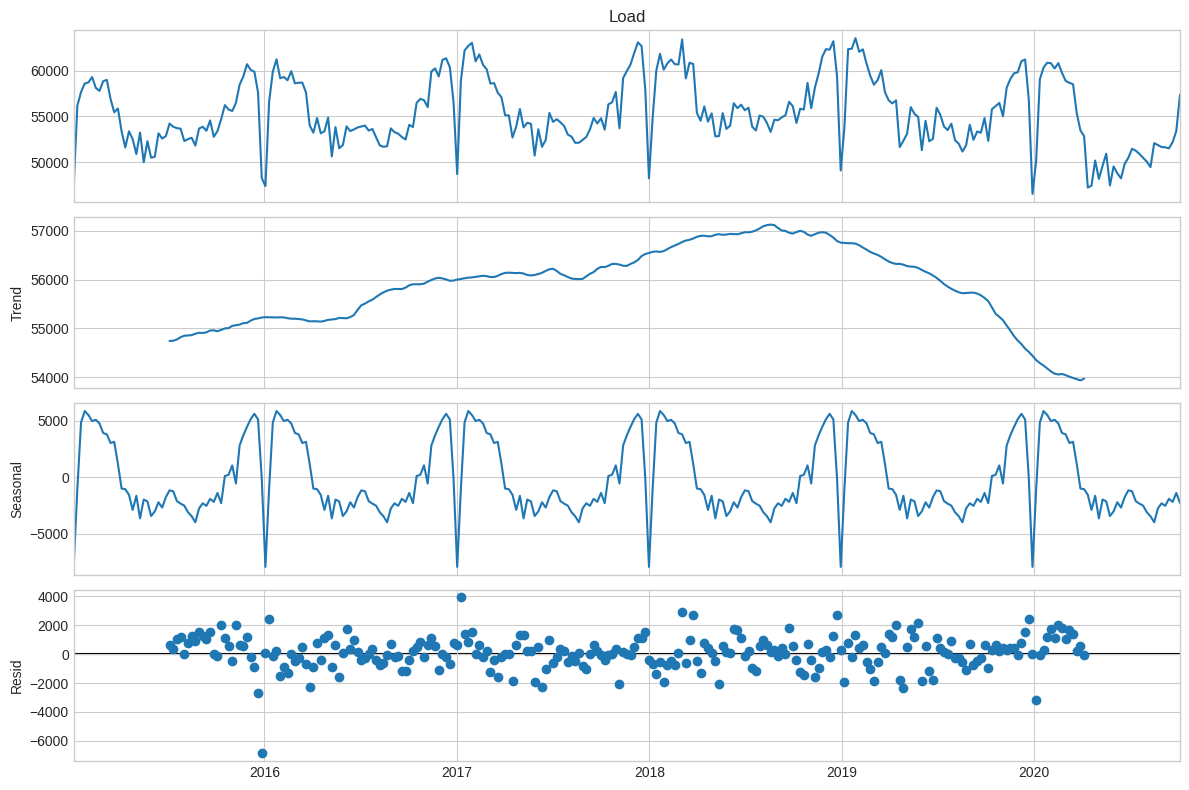

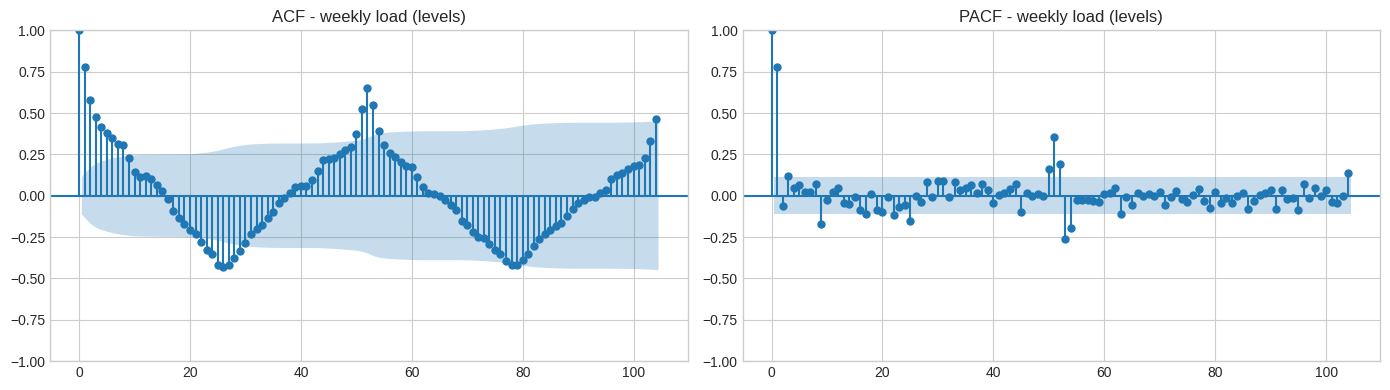

In [9]:
# --- 2. Initial Plots & EDA ---
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
df_daily['Load'].plot(ax=ax[0], title='Daily German Electricity Load (mean MW)', color='blue')
df_weekly['Load'].plot(ax=ax[1], title='Weekly German Electricity Load (mean MW)', color='green')
plt.tight_layout()
plt.show()

# --- 3. Decomposition ---
# Decompose weekly data (period=52 for annual seasonality in weekly data)
decomp = seasonal_decompose(df_weekly['Load'], period=52, model='additive')
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_weekly['Load'], lags=104, ax=ax[0])
plot_pacf(df_weekly['Load'], lags=104, ax=ax[1])
ax[0].set_title('ACF - weekly load (levels)')
ax[1].set_title('PACF - weekly load (levels)')
plt.tight_layout()
plt.show()


In [10]:
# --- 4. Stationarity testing ---

def adf_test(series, label):
    res = adfuller(series.dropna(), autolag='AIC')
    verdict = "Stationary" if res[1] < 0.05 else "Non-Stationary"
    print(f"[ADF]  {label:40s} stat={res[0]:8.4f}  p={res[1]:.4f}  -> {verdict}")

def kpss_test(series, label):
    res = kpss(series.dropna(), regression='c', nlags='auto')
    verdict = "Non-Stationary" if res[1] < 0.05 else "Stationary"
    print(f"[KPSS] {label:40s} stat={res[0]:8.4f}  p={res[1]:.4f}  -> {verdict}")

for label, series in [
    ("Weekly - levels", df_weekly['Load']),
    ("Weekly - 1st difference", df_weekly['Load'].diff()),
    ("Weekly - seasonal difference (lag 52)", df_weekly['Load'].diff(52)),
]:
    adf_test(series, label)
    kpss_test(series, label)
    print()


[ADF]  Weekly - levels                          stat= -4.0475  p=0.0012  -> Stationary
[KPSS] Weekly - levels                          stat=  0.1604  p=0.1000  -> Stationary

[ADF]  Weekly - 1st difference                  stat= -7.0693  p=0.0000  -> Stationary
[KPSS] Weekly - 1st difference                  stat=  0.0558  p=0.1000  -> Stationary

[ADF]  Weekly - seasonal difference (lag 52)    stat= -4.2951  p=0.0005  -> Stationary
[KPSS] Weekly - seasonal difference (lag 52)    stat=  1.3419  p=0.0100  -> Non-Stationary



## Part 2: Benchmark Forecasts (Mean, Naive, Seasonal Naive, Drift)

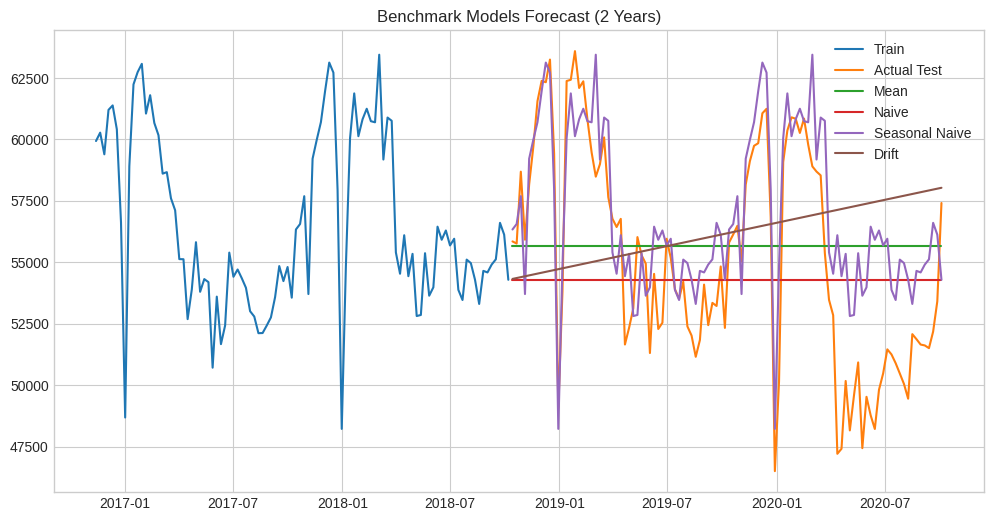

In [11]:
# --- Train/Test Split (2-Year Horizon = 104 weeks) ---
horizon = 104
train_wk = df_weekly.iloc[:-horizon]
test_wk = df_weekly.iloc[-horizon:]

# --- Benchmark 1: Mean Forecast ---
mean_pred = np.full(horizon, train_wk['Load'].mean())

# --- Benchmark 2: Naive Forecast (Last observed value) ---
naive_pred = np.full(horizon, train_wk['Load'].iloc[-1])

# --- Benchmark 3: Seasonal Naive (Last year's same week) ---
seasonal_naive_pred = np.tile(train_wk['Load'].iloc[-52:].values,
                               int(np.ceil(horizon / 52)))[:horizon]

# --- Benchmark 4: Drift Forecast ---
y1, y2 = train_wk['Load'].iloc[0], train_wk['Load'].iloc[-1]
slope = (y2 - y1) / (len(train_wk) - 1)
drift_pred = [y2 + slope * i for i in range(1, horizon + 1)]

# Plot Benchmarks
plt.figure(figsize=(12, 6))
plt.plot(train_wk.index[-100:], train_wk['Load'].iloc[-100:], label='Train')
plt.plot(test_wk.index, test_wk['Load'], label='Actual Test')
plt.plot(test_wk.index, mean_pred, label='Mean')
plt.plot(test_wk.index, naive_pred, label='Naive')
plt.plot(test_wk.index, seasonal_naive_pred, label='Seasonal Naive')
plt.plot(test_wk.index, drift_pred, label='Drift')
plt.legend()
plt.title('Benchmark Models Forecast (2 Years)')
plt.show()


In [12]:
# Evaluation
results_summary = []

def eval_metrics(actual, pred, name, store=None):
    actual = np.asarray(actual, dtype=float).ravel()
    pred = np.asarray(pred, dtype=float).ravel()
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"{name:32s} RMSE: {rmse:9.2f}   MAE: {mae:9.2f}   MAPE: {mape:6.2f}%")
    if store is not None:
        store.append({"model": name, "RMSE": rmse, "MAE": mae, "MAPE": mape})
    return rmse, mae, mape


eval_metrics(test_wk['Load'], mean_pred, "Mean", results_summary)
eval_metrics(test_wk['Load'], naive_pred, "Naive", results_summary)
eval_metrics(test_wk['Load'], seasonal_naive_pred, "Seasonal Naive", results_summary)
eval_metrics(test_wk['Load'], drift_pred, "Drift", results_summary)


Mean                             RMSE:   4397.30   MAE:   3788.83   MAPE:   6.97%
Naive                            RMSE:   4459.11   MAE:   3783.20   MAPE:   6.79%
Seasonal Naive                   RMSE:   3006.76   MAE:   2318.52   MAPE:   4.41%
Drift                            RMSE:   5117.96   MAE:   4339.89   MAPE:   8.05%


(np.float64(5117.957264105131),
 4339.890674447435,
 np.float64(8.049685103165077))

## Part 3: SARIMA Model

(0, 0, 0) AIC: 1635.3429870141863
(0, 0, 1) AIC: 1603.930037282084
(0, 0, 2) AIC: 1585.5423240687605
(0, 0, 3) AIC: 1560.7427572333638
(0, 0, 4) AIC: 1541.1930228652286
(0, 0, 5) AIC: 1527.5068608549368
(0, 0, 6) AIC: 1508.7206521500675
(0, 1, 0) AIC: 1617.8591156399543
(0, 1, 1) AIC: 1582.1222194675934
(0, 1, 2) AIC: 1564.696966859014
(0, 1, 3) AIC: 1546.1741003504997
(0, 1, 4) AIC: 1527.85126651956
(0, 1, 5) AIC: 1509.0629442397146
(0, 1, 6) AIC: 1490.461383866015
(0, 2, 0) AIC: 1697.13320092045
(0, 2, 1) AIC: 1604.3259408428564
(0, 2, 2) AIC: 1567.7875101611876
(0, 2, 3) AIC: 1546.1169827418423
(0, 2, 4) AIC: 1521.0714275839757
(0, 2, 5) AIC: 1503.304964109002
(0, 2, 6) AIC: 1485.8169044986378
(1, 0, 0) AIC: 1614.0075964427274
(1, 0, 1) AIC: 1594.2381055003957
(1, 0, 2) AIC: 1576.8877745853383
(1, 0, 3) AIC: 1562.1818449817058
(1, 0, 4) AIC: 1546.5821070681154
(1, 0, 5) AIC: 1529.6863673628409
(1, 0, 6) AIC: 1511.483031880073
(1, 1, 0) AIC: 1606.4062594269396
(1, 1, 1) AIC: 1579.985

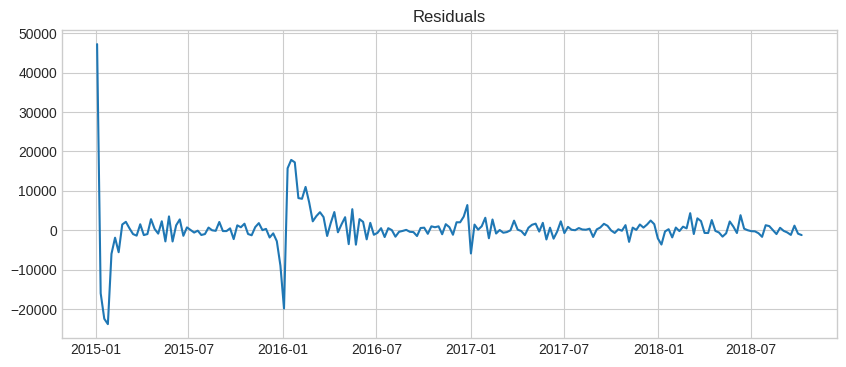

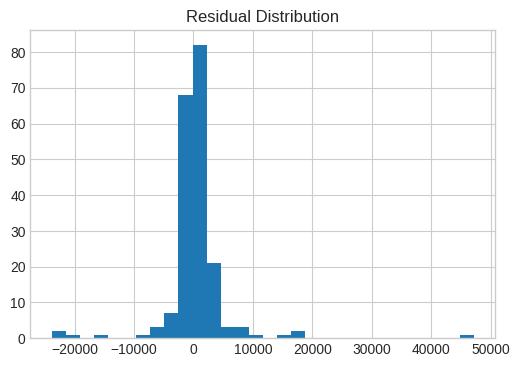

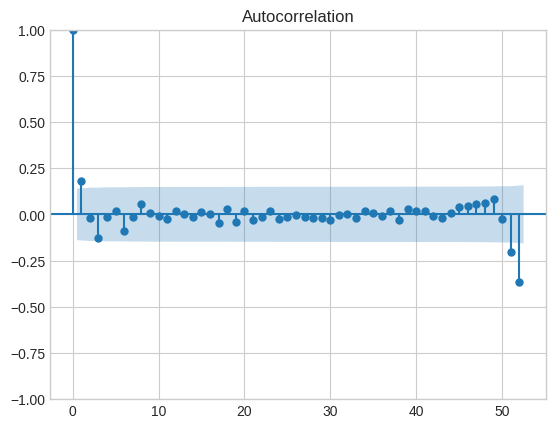

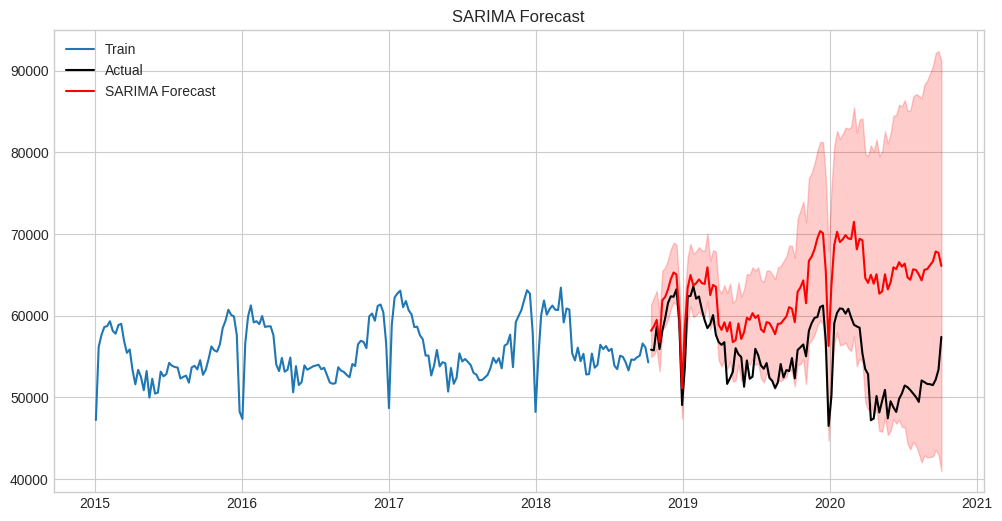

SARIMA RMSE: 9470.263043994419


In [13]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np

# --- Re-defining Data Loading and Preparation for self-contained execution ---
url = 'https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv'
df_opsd = pd.read_csv(url, index_col='utc_timestamp', parse_dates=True)
df_opsd.index = pd.to_datetime(df_opsd.index, utc=True).tz_localize(None)
df = df_opsd.loc['2015-01-01':].copy()
load_col = 'DE_load_actual_entsoe_transparency'
df = df[[load_col]].rename(columns={load_col: 'Load'})
df['Load'] = df['Load'].ffill()
df_daily = df.resample('D').mean()
df_weekly = df.resample('W').mean().dropna() # Added .dropna() here to remove any leading NaNs

# Define train_wk, test_wk, and horizon
horizon = 104
train_wk = df_weekly.iloc[:-horizon]
test_wk = df_weekly.iloc[-horizon:]

seasonal_order = (1, 1, 1, 52)

best_aic = None
best_order = None
all_results = []

for p in range(0, 7):      # 0,1,2,3,4,5,6
    for d in range(0, 3):  # 0,1,2
        for q in range(0, 7):  # 0,1,2,3,4,5,6
            order = (p, d, q)
            try:
                model = SARIMAX(
                    train_wk['Load'], # Use train_wk['Load']
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fit = model.fit(disp=False)
                aic = fit.aic
                all_results.append((p, d, q, aic))
                print(order, "AIC:", aic)

                if best_aic is None or aic < best_aic:
                    best_aic = aic
                    best_order = order
            except Exception as e:

                print(order, "failed:", e)
                continue

print("\nBest order found:", best_order, "with AIC:", best_aic)


results_df = pd.DataFrame(all_results, columns=["p", "d", "q", "aic"])
results_df = results_df.sort_values("aic")
results_df.to_csv("sarima_grid_search_results.csv", index=False)
print(results_df.head(10))

# ---------- Step 2: Fit the best model ----------

final_model = SARIMAX(
    train_wk['Load'], # Use train_wk['Load']
    order=best_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())

# ---------- Step 3: Check residuals ----------

residuals = final_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

plot_acf(residuals.dropna(), lags=52)
plt.show()

# ---------- Step 4: Forecast last 2 years ----------

forecast = final_fit.get_forecast(steps=horizon)
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train_wk.index, train_wk['Load'], label="Train")
plt.plot(test_wk.index, test_wk['Load'], label="Actual", color="black")
plt.plot(test_wk.index, forecast_values, label="SARIMA Forecast", color="red")
plt.fill_between(test_wk.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="red", alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

# ---------- Step 5: RMSE ----------

def rmse(actual, predicted):
    errors = actual.values - predicted.values
    return np.sqrt(np.mean(errors ** 2))

print("SARIMA RMSE:", rmse(test_wk['Load'], forecast_values))

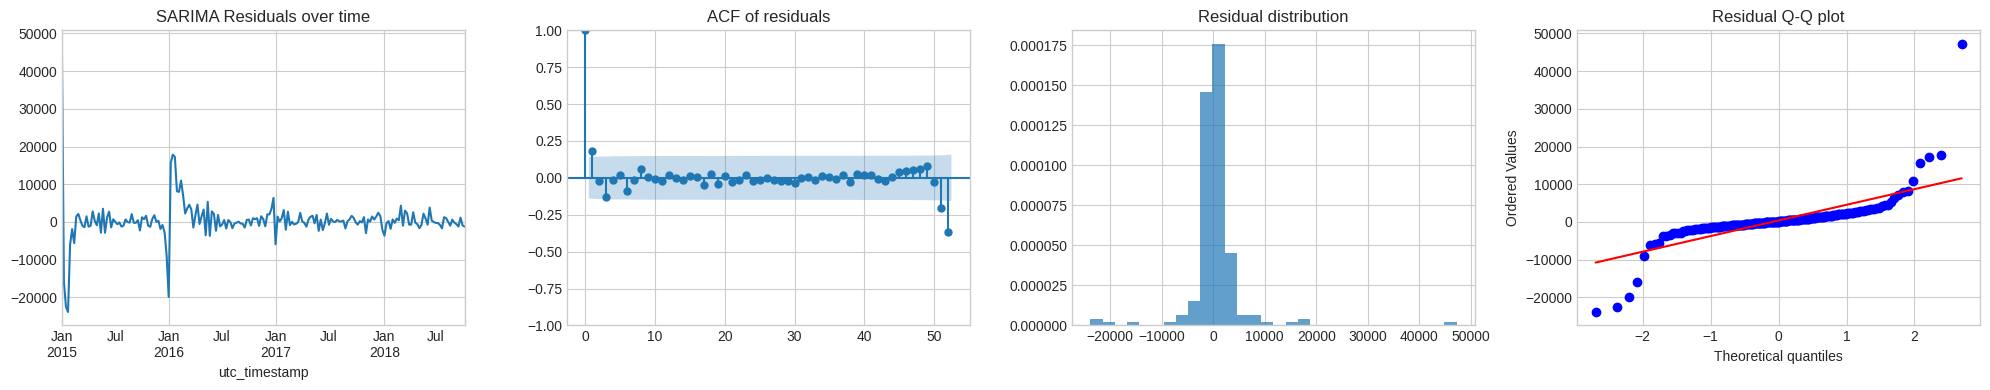

Ljung-Box test (H0: residuals are uncorrelated / white noise):
      lb_stat  lb_pvalue
10  12.489748   0.253615
20  13.906235   0.835218
52  67.995359   0.067405


In [15]:
sarima_res = final_fit # Assign final_fit to sarima_res for diagnostics

# --- Residual diagnostics ---
resid = sarima_res.resid.dropna()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
resid.plot(ax=axes[0], title='SARIMA Residuals over time')
plot_acf(resid, ax=axes[1], lags=52)
axes[1].set_title('ACF of residuals')
axes[2].hist(resid, bins=30, density=True, alpha=0.7)
axes[2].set_title('Residual distribution')
stats.probplot(resid, dist='norm', plot=axes[3])
axes[3].set_title('Residual Q-Q plot')
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(resid, lags=[10, 20, 52], return_df=True)
print("Ljung-Box test (H0: residuals are uncorrelated / white noise):")
print(lb_test)

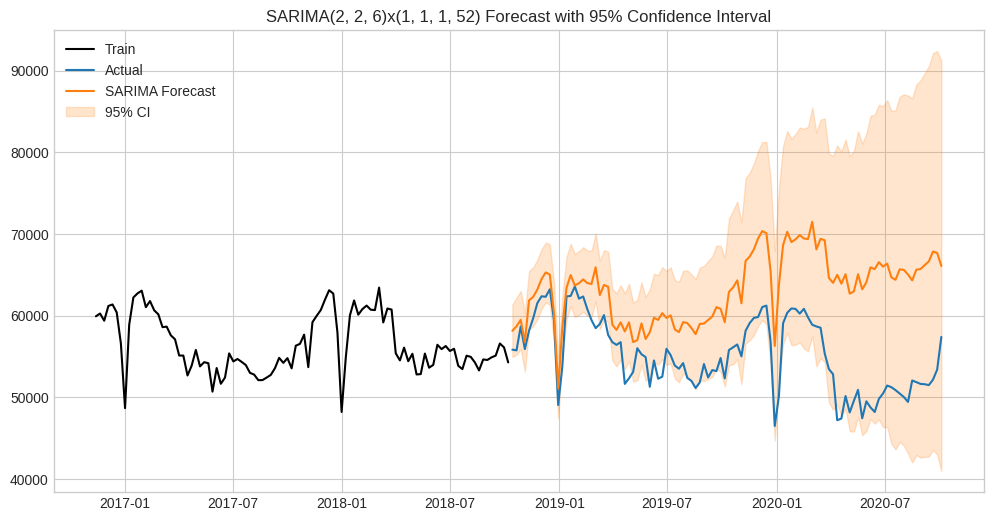

SARIMA                           RMSE:   9470.26   MAE:   8108.35   MAPE:  15.24%


(np.float64(9470.263043994419),
 8108.347597185939,
 np.float64(15.243801304707336))

In [17]:
# --- Forecast with confidence intervals ---
forecast_obj = sarima_res.get_forecast(steps=horizon)
sarima_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

plt.figure(figsize=(12, 6))
plt.plot(train_wk.index[-100:], train_wk['Load'].iloc[-100:], label='Train', color='black')
plt.plot(test_wk.index, test_wk['Load'], label='Actual', color='tab:blue')
plt.plot(test_wk.index, sarima_pred, label='SARIMA Forecast', color='tab:orange')
plt.fill_between(test_wk.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color='tab:orange', alpha=0.2, label='95% CI')
plt.legend()
plt.title(f'SARIMA{best_order}x{seasonal_order} Forecast with 95% Confidence Interval')
plt.show()

eval_metrics(test_wk['Load'], sarima_pred, "SARIMA", results_summary)

## Part 4: Add Temperature (SARIMAX)

In [18]:
print("Fetching Berlin temperature data (Open-Meteo archive)...")
meteo_url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=52.52&longitude=13.41"
    "&start_date=2015-01-01&end_date=2020-10-06"
    "&daily=temperature_2m_mean&timezone=UTC"
)
res = requests.get(meteo_url).json()

temp_df = pd.DataFrame({
    'date': pd.to_datetime(res['daily']['time']),
    'Temperature': res['daily']['temperature_2m_mean'],
}).set_index('date')

temp_weekly = temp_df.resample('W').mean()

df_exo = df_weekly.join(temp_weekly, how='inner')
print(f"Weeks with matched load + temperature data: {len(df_exo)} (out of {len(df_weekly)})")

train_exo = df_exo.iloc[:-horizon]
test_exo = df_exo.iloc[-horizon:]


Fetching Berlin temperature data (Open-Meteo archive)...
Weeks with matched load + temperature data: 301 (out of 301)


                                      SARIMAX Results                                       
Dep. Variable:                                 Load   No. Observations:                  197
Model:             SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -728.229
Date:                              Tue, 14 Jul 2026   AIC                           1480.459
Time:                                      13:11:42   BIC                           1509.629
Sample:                                  01-04-2015   HQIC                          1492.185
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Temperature   -87.2852     64.459     -1.354      0.176    -213.623      39.053
ar.L1          -

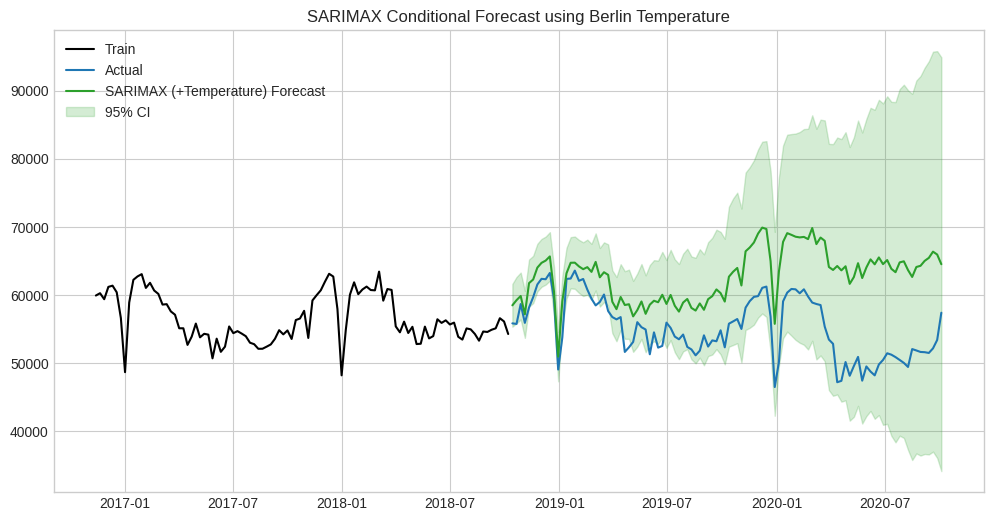

SARIMAX (with Temp)              RMSE:   8883.05   MAE:   7668.81   MAPE:  14.42%


(np.float64(8883.047825515134),
 7668.807237289149,
 np.float64(14.4189666753267))

In [20]:
sarimax = SARIMAX(train_exo['Load'], exog=train_exo[['Temperature']],
                   order=best_order, seasonal_order=seasonal_order,
                   enforce_stationarity=False, enforce_invertibility=False)
sarimax_res = sarimax.fit(disp=False)
print(sarimax_res.summary())

sarimax_forecast_obj = sarimax_res.get_forecast(steps=horizon, exog=test_exo[['Temperature']])
sarimax_pred = sarimax_forecast_obj.predicted_mean
sarimax_ci = sarimax_forecast_obj.conf_int(alpha=0.05)

plt.figure(figsize=(12, 6))
plt.plot(train_exo.index[-100:], train_exo['Load'].iloc[-100:], label='Train', color='black')
plt.plot(test_exo.index, test_exo['Load'], label='Actual', color='tab:blue')
plt.plot(test_exo.index, sarimax_pred, label='SARIMAX (+Temperature) Forecast', color='tab:green')
plt.fill_between(test_exo.index, sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1],
                  color='tab:green', alpha=0.2, label='95% CI')
plt.legend()
plt.title('SARIMAX Conditional Forecast using Berlin Temperature')
plt.show()

eval_metrics(test_exo['Load'], sarimax_pred, "SARIMAX (with Temp)", results_summary)

## Part 5: Feature-Based Model (Random Forest)

In [21]:
df_feat = df_exo.copy()
df_feat['Lag_1'] = df_feat['Load'].shift(1)
df_feat['Lag_2'] = df_feat['Load'].shift(2)
df_feat['Lag_52'] = df_feat['Load'].shift(52)  # last year, same week
df_feat['RollMean_4'] = df_feat['Load'].shift(1).rolling(4).mean()
df_feat['Month'] = df_feat.index.month
df_feat['WeekOfYear'] = df_feat.index.isocalendar().week.astype(int)
df_feat.dropna(inplace=True)

feature_cols = ['Temperature', 'Lag_1', 'Lag_2', 'Lag_52', 'RollMean_4', 'Month', 'WeekOfYear']

train_rf = df_feat.iloc[:-horizon]
test_rf = df_feat.iloc[-horizon:]

X_train = train_rf[feature_cols]
y_train = train_rf['Load']

rf = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=2,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=8, min_samples_leaf=2, n_estimators=300,
                      n_jobs=-1, random_state=42)

Random Forest (recursive)        RMSE:   3048.74   MAE:   2309.11   MAPE:   4.44%

Feature importances:
Lag_52         0.797125
Lag_1          0.067108
WeekOfYear     0.055424
Temperature    0.043671
RollMean_4     0.019467
Lag_2          0.013102
Month          0.004103
dtype: float64


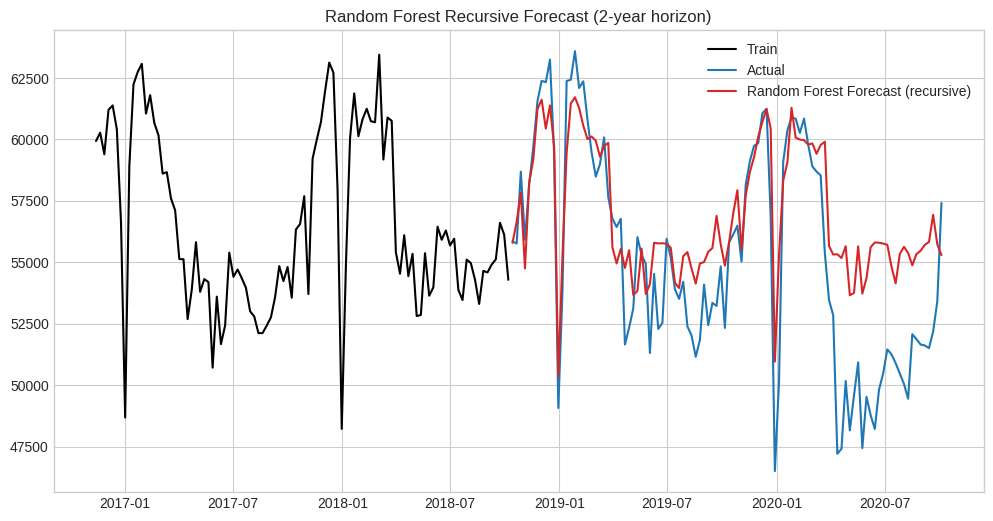

In [22]:
history = df_feat['Load'].loc[:train_rf.index[-1]].copy()
future_temp = df_exo['Temperature'].loc[test_rf.index[0]:test_rf.index[-1]]  # observed/conditional, as in Part 4

rf_preds = []
for date, temp_val in future_temp.items():
    row = {
        'Temperature': temp_val,
        'Lag_1': history.iloc[-1],
        'Lag_2': history.iloc[-2],
        'Lag_52': history.iloc[-52],
        'RollMean_4': history.iloc[-4:].mean(),
        'Month': date.month,
        'WeekOfYear': date.isocalendar().week,
    }
    X_row = pd.DataFrame([row])[feature_cols]
    y_hat = rf.predict(X_row)[0]
    rf_preds.append(y_hat)
    history.loc[date] = y_hat  # feed prediction back in for next week's lags

rf_pred = pd.Series(rf_preds, index=test_rf.index)
eval_metrics(test_rf['Load'], rf_pred, "Random Forest (recursive)", results_summary)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

plt.figure(figsize=(12, 6))
plt.plot(train_rf.index[-100:], train_rf['Load'].iloc[-100:], label='Train', color='black')
plt.plot(test_rf.index, test_rf['Load'], label='Actual', color='tab:blue')
plt.plot(test_rf.index, rf_pred, label='Random Forest Forecast (recursive)', color='tab:red')
plt.legend()
plt.title('Random Forest Recursive Forecast (2-year horizon)')
plt.show()


## Part 6: LSTM on Hourly Data

In [23]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Load']].values)

def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

h_horizon = 17520  # ~2 years of hours

def build_lstm(look_back, units=50, dropout=0.2):
    m = Sequential()
    m.add(LSTM(units, return_sequences=True, input_shape=(look_back, 1)))
    m.add(Dropout(dropout))
    m.add(LSTM(units // 2))
    m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(loss='mean_squared_error', optimizer='adam')
    return m


In [24]:
scaled_train_full = scaled_data[:-h_horizon]

best_val_loss, best_cfg = float('inf'), None
for look_back in [24, 48]:
    for units in [32, 50]:
        X_all, y_all = create_dataset(scaled_train_full, look_back)
        X_all = X_all.reshape(-1, look_back, 1)
        split = int(len(X_all) * 0.9)
        X_tr, y_tr = X_all[:split], y_all[:split]
        X_val, y_val = X_all[split:], y_all[split:]

        m = build_lstm(look_back, units=units)
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        hist = m.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=8,
                     batch_size=256, callbacks=[es], verbose=0)
        val_loss = min(hist.history['val_loss'])
        print(f"look_back={look_back}, units={units} -> val_loss={val_loss:.6f}")
        if val_loss < best_val_loss:
            best_val_loss, best_cfg = val_loss, {'look_back': look_back, 'units': units}

print(f"\nBest config: {best_cfg} (val_loss={best_val_loss:.6f})")
look_back, units = best_cfg['look_back'], best_cfg['units']


look_back=24, units=32 -> val_loss=0.002338
look_back=24, units=50 -> val_loss=0.001946
look_back=48, units=32 -> val_loss=0.001713
look_back=48, units=50 -> val_loss=0.001934

Best config: {'look_back': 48, 'units': 32} (val_loss=0.001713)


Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0695 - val_loss: 0.0348
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0351 - val_loss: 0.0163
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0178 - val_loss: 0.0066
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0134 - val_loss: 0.0048
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0116 - val_loss: 0.0039
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0104 - val_loss: 0.0037
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0094 - val_loss: 0.0030
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0086 - val_loss: 0.0026
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0079 - val_loss: 0.0024
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0070 - val_loss: 0.0019
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0066 - val_loss: 0.0016
Epoch 12/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9m

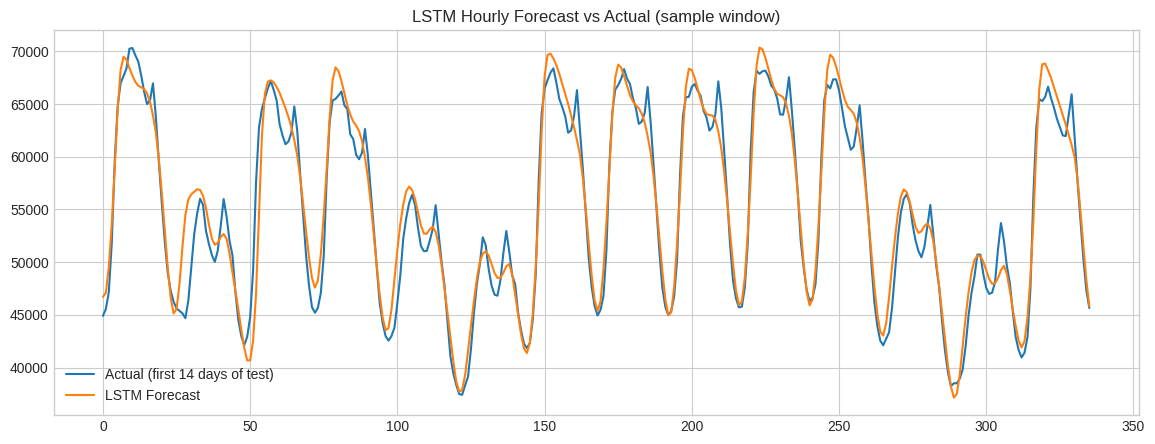

In [25]:
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train_lstm, X_test_lstm = X[:-h_horizon], X[-h_horizon:]
y_train_lstm, y_test_lstm = y[:-h_horizon], y[-h_horizon:]

model = build_lstm(look_back, units=units)
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=256,
          validation_split=0.1, callbacks=[es], verbose=1)

lstm_pred_scaled = model.predict(X_test_lstm)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_unscaled = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

eval_metrics(y_test_unscaled, lstm_pred, "LSTM (Hourly, 1-step walk-forward)", results_summary)

plt.figure(figsize=(14, 5))
plt.plot(y_test_unscaled[:24 * 14], label='Actual (first 14 days of test)')
plt.plot(lstm_pred[:24 * 14], label='LSTM Forecast')
plt.legend()
plt.title('LSTM Hourly Forecast vs Actual (sample window)')
plt.show()


## Summary: All Models Compared

In [26]:
results_df = pd.DataFrame(results_summary).sort_values('RMSE').reset_index(drop=True)
print(results_df.to_string(index=False))
results_df


                             model        RMSE         MAE      MAPE
LSTM (Hourly, 1-step walk-forward) 1797.305287 1333.374945  2.509563
                    Seasonal Naive 3006.760812 2318.520585  4.408920
         Random Forest (recursive) 3048.744517 2309.112161  4.439487
                              Mean 4397.299694 3788.833122  6.969238
                             Naive 4459.108546 3783.202934  6.790082
                             Drift 5117.957264 4339.890674  8.049685
               SARIMAX (with Temp) 8883.047826 7668.807237 14.418967
                            SARIMA 9470.263044 8108.347597 15.243801


,model,RMSE,MAE,MAPE
0,"LSTM (Hourly, 1-step walk-forward)",1797.305287,1333.374945,2.509563
1,Seasonal Naive,3006.760812,2318.520585,4.408920
2,Random Forest (recursive),3048.744517,2309.112161,4.439487
3,Mean,4397.299694,3788.833122,6.969238
4,Naive,4459.108546,3783.202934,6.790082
5,Drift,5117.957264,4339.890674,8.049685
6,SARIMAX (with Temp),8883.047826,7668.807237,14.418967
7,SARIMA,9470.263044,8108.347597,15.243801
